In [437]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn import datasets
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import TargetEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

X_train = pd.read_parquet("../data/processed/X_train.parquet")
X_test = pd.read_parquet("../data/processed/X_test.parquet")
X_val = pd.read_parquet("../data/processed/X_val.parquet")

y_train = pd.read_parquet("../data/processed/y_train.parquet")["price"]
y_val = pd.read_parquet("../data/processed/y_val.parquet")["price"]
y_test = pd.read_parquet("../data/processed/y_test.parquet")["price"]

In [438]:
val_hashes = pd.util.hash_pandas_object(X_val, index=False)
train_hashes = pd.util.hash_pandas_object(X_train, index=False)

In [439]:
val_group = val_hashes.groupby(val_hashes).groups
train_group = train_hashes.groupby(train_hashes).groups

In [440]:
mask = np.isin(val_hashes, train_hashes)

In [441]:
matched_val = X_val.loc[mask]

In [442]:
len(matched_val)
len(X_val)

266271

In [443]:
len(matched_val) / len(X_val) * 100

19.202992440032897

In [444]:
train_lookup = pd.DataFrame({
    "hash": train_hashes,
    "train_price": y_train
})

val_lookup = pd.DataFrame({
    "hash": val_hashes,
    "val_price": y_val
})

In [445]:
matched_prices = val_lookup.merge(
    train_lookup,
    on="hash",
    how="inner"
)

In [446]:
different_prices = matched_prices[
    matched_prices["val_price"] != matched_prices["train_price"]
]

In [447]:
len(different_prices)

171752

In [448]:
different_prices.head(20)

,hash,val_price,train_price
0,17846470405846719530,59286.0,54255.0
1,6733417902417196245,21178.0,24913.0
2,6733417902417196245,21178.0,25741.0
3,6733417902417196245,21178.0,24366.0
4,6733417902417196245,21178.0,24090.0
5,6733417902417196245,21178.0,26288.0
6,4212990437395690760,26181.0,23004.0
7,4212990437395690760,26181.0,23827.0
8,4212990437395690760,26181.0,23472.0
9,4212990437395690760,26181.0,23280.0


In [449]:
different_prices.describe()

,hash,val_price,train_price
count,1.717520e+05,171752.000000,1.717520e+05
mean,9.183646e+18,38657.968544,3.863267e+04
std,5.323869e+18,16832.940019,1.660666e+04
min,5.817745e+14,9270.000000,9.285000e+03
25%,4.649668e+18,26257.000000,2.624900e+04
50%,9.098538e+18,36381.000000,3.638500e+04
75%,1.385261e+19,47466.000000,4.753500e+04
max,1.844541e+19,425460.000000,1.116711e+06


In [450]:
different_prices["price_difference"] = (
    different_prices["val_price"] - different_prices["train_price"]
).abs()

different_prices.sort_values(
    "price_difference",
    ascending=False
).head(30)

,hash,val_price,train_price,price_difference
123399,16468349563739211745,57500.0,1116711.0,1059211.0
32745,16468349563739211745,59475.0,1116711.0,1057236.0
92438,6713839979747926329,425460.0,32368.0,393092.0
92428,6713839979747926329,425460.0,32382.0,393078.0
92432,6713839979747926329,425460.0,32828.0,392632.0
44333,6713839979747926329,424060.0,32368.0,391692.0
44323,6713839979747926329,424060.0,32382.0,391678.0
44327,6713839979747926329,424060.0,32828.0,391232.0
92437,6713839979747926329,425460.0,35386.0,390074.0
92425,6713839979747926329,425460.0,35846.0,389614.0


In [451]:
suspect_hash = 6713839979747926329

val_rows = X_val.loc[val_hashes == suspect_hash].copy()
val_rows["price"] = y_val.loc[val_rows.index]

train_rows = X_train.loc[train_hashes == suspect_hash].copy()
train_rows["price"] = y_train.loc[train_rows.index]

In [452]:
val_rows

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,price
908527,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,424060.0
908532,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,425460.0
907408,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,42867.0
907359,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,52345.0


In [453]:
train_rows.head(20)

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,price
907663,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,48727.0
906951,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,35846.0
907648,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,48169.0
907369,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,46421.0
906836,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,32382.0
907875,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,50154.0
907354,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,51991.0
907289,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,51787.0
906916,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,32828.0
907320,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,42407.0


Drama in the shhaaat

Investigated why train RMSE > validation RMSE.

Turns out my earlier Mercedes/BMW cleanup wasn't comprehensive. I removed the symptoms, not the root cause.

Found more corrupted prices hiding in identical-feature groups, including a GMC Acadia listed at ~$400k 💀

Next: systematically clean the root issue → retrain → re-evaluate.

In [454]:
vehicle_lookup = X_train.copy()
vehicle_lookup["hash"] = train_hashes.values

In [455]:
vehicle_lookup = vehicle_lookup[
    ["hash", "make_name", "model_name", "year", "trim_name", "mileage"]
]

In [456]:
vehicle_lookup = vehicle_lookup.drop_duplicates(subset="hash")

In [457]:
val_prices = val_lookup.rename(columns={"val_price": "price"})
train_prices = train_lookup.rename(columns={"train_price": "price"})

all_prices = pd.concat([train_prices, val_prices], ignore_index=True)

In [458]:
price_groups = all_prices.groupby("hash")

In [459]:
price_stats = price_groups["price"].quantile([0.25, 0.75]).unstack()

In [460]:
price_stats.columns = ["Q1", "Q3"]
price_stats["IQR"] = price_stats["Q3"] - price_stats["Q1"]

In [461]:
price_stats["lower_bound"] = price_stats["Q1"] - 1.5 * price_stats["IQR"]
price_stats["upper_bound"] = price_stats["Q3"] + 1.5 * price_stats["IQR"]

In [462]:
prices_with_bounds = all_prices.merge(
    price_stats,
    on="hash",
    how="left"
)

In [463]:
price_stats.head()

,Q1,Q3,IQR,lower_bound,upper_bound
hash,,,,,
1187703273057,41912.0,41912.0,0.0,41912.0,41912.0
13228759559581,26125.0,26125.0,0.0,26125.0,26125.0
22701073440238,23395.0,23395.0,0.0,23395.0,23395.0
28112847962006,24492.0,24492.0,0.0,24492.0,24492.0
28186126298156,39988.0,39988.0,0.0,39988.0,39988.0


In [464]:
price_stats = price_stats.reset_index()

In [465]:
price_stats.head()

,hash,Q1,Q3,IQR,lower_bound,upper_bound
0,1187703273057,41912.0,41912.0,0.0,41912.0,41912.0
1,13228759559581,26125.0,26125.0,0.0,26125.0,26125.0
2,22701073440238,23395.0,23395.0,0.0,23395.0,23395.0
3,28112847962006,24492.0,24492.0,0.0,24492.0,24492.0
4,28186126298156,39988.0,39988.0,0.0,39988.0,39988.0


In [466]:
prices_with_bounds = all_prices.merge(
    price_stats,
    on="hash",
    how="left"
)

In [467]:
outlier_mask = (
    (prices_with_bounds["price"] < prices_with_bounds["lower_bound"]) |
    (prices_with_bounds["price"] > prices_with_bounds["upper_bound"])
)

In [468]:
price_outliers = prices_with_bounds.loc[outlier_mask]

In [469]:
price_outliers

,hash,price,Q1,Q3,IQR,lower_bound,upper_bound
360,11492454641014865074,37129.0,33689.00,34660.00,971.00,32232.500,36116.500
382,18354971751878231366,30741.0,31359.75,31666.00,306.25,30900.375,32125.375
506,15939350068581148109,64508.0,60046.00,60994.00,948.00,58624.000,62416.000
988,1481733677770707769,70395.0,70631.25,70785.00,153.75,70400.625,71015.625
1309,15400783789799948445,31028.0,31164.50,31248.50,84.00,31038.500,31374.500
...,...,...,...,...,...,...,...
2395270,462773034933269947,22439.0,19923.50,20907.00,983.50,18448.250,22382.250
2395321,4176720475846868057,25215.0,26245.00,26275.00,30.00,26200.000,26320.000
2395337,14762203832802342259,45453.0,39821.50,41947.00,2125.50,36633.250,45135.250
2395564,14527353990557763932,34560.0,34762.50,34800.00,37.50,34706.250,34856.250


In [470]:
median_prices = price_groups["price"].median()

In [471]:
median_prices.head()

hash
1187703273057     41912.0
13228759559581    26125.0
22701073440238    23395.0
28112847962006    24492.0
28186126298156    39988.0
Name: price, dtype: float64

In [472]:
median_prices = median_prices.reset_index(name="median_price")

In [473]:
prices_with_bounds = prices_with_bounds.merge(
    median_prices,
    on="hash",
    how="left"
)

In [474]:
prices_with_bounds["price_ratio"] = (
    prices_with_bounds["price"] / prices_with_bounds["median_price"]
)

In [475]:
prices_with_bounds["price_ratio"]

0          1.0
1          1.0
2          1.0
3          1.0
4          1.0
          ... 
2396470    1.0
2396471    1.0
2396472    1.0
2396473    1.0
2396474    1.0
Name: price_ratio, Length: 2396475, dtype: float64

In [476]:
prices_with_bounds["price_ratio"].sort_values(ascending = False).head(20)

41194      18.875318
9447       10.112927
2274359     8.832652
2199403     8.803587
1834262     8.756254
2070733     8.072827
1789711     3.755831
747564      3.151632
1852629     2.890950
1940851     2.527994
645841      2.303703
2193739     2.298284
688861      2.226770
2332802     2.218362
358795      2.216688
1029122     2.200260
780581      2.102827
2124651     2.090569
1181871     2.070429
1601663     2.035143
Name: price_ratio, dtype: float64

In [477]:
sus_hash = 16468349563739211745
val_rows = X_val.loc[val_hashes == sus_hash].copy()
val_rows["price"] = y_val.loc[val_rows.index]

train_rows = X_train.loc[train_hashes == sus_hash].copy()
train_rows["price"] = y_train.loc[train_rows.index]

In [478]:
train_rows

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,price
2537100,Laguna Niguel,I4,Not Reported,Gasoline,Not Reported,180.0,True,Mercedes-Benz,1.0,E-Class,...,A,E 350 Sedan RWD,Unknown,2021,0,1,False,False,False,1116711.0
2535958,Laguna Niguel,I4,Not Reported,Gasoline,Not Reported,180.0,True,Mercedes-Benz,1.0,E-Class,...,A,E 350 Sedan RWD,Unknown,2021,0,1,False,False,False,58850.0


In [479]:
val_rows

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,price
2536065,Laguna Niguel,I4,Not Reported,Gasoline,Not Reported,180.0,True,Mercedes-Benz,1.0,E-Class,...,A,E 350 Sedan RWD,Unknown,2021,0,1,False,False,False,59475.0
2535528,Laguna Niguel,I4,Not Reported,Gasoline,Not Reported,180.0,True,Mercedes-Benz,1.0,E-Class,...,A,E 350 Sedan RWD,Unknown,2021,0,1,False,False,False,57500.0


In [480]:
prices_with_vehicle = prices_with_bounds.merge(
    vehicle_lookup,
    on="hash",
    how="left"
)

In [481]:
prices_with_vehicle.sort_values(
    "price_ratio",
    ascending=False
)[
    [
        "make_name",
        "model_name",
        "year",
        "trim_name",
        "mileage",
        "price",
        "median_price",
        "price_ratio"
    ]
]

,make_name,model_name,year,trim_name,mileage,price,median_price,price_ratio
41194,Mercedes-Benz,E-Class,2021.0,E 350 Sedan RWD,1.0,1116711.0,59162.5,18.875318
9447,Jeep,Compass,2021.0,Unknown,6.0,320150.0,31657.5,10.112927
2274359,GMC,Acadia,2021.0,Unknown,5.0,425460.0,48169.0,8.832652
2199403,GMC,Acadia,2021.0,Unknown,5.0,424060.0,48169.0,8.803587
1834262,GMC,Acadia,2021.0,Unknown,5.0,421780.0,48169.0,8.756254
...,...,...,...,...,...,...,...,...
1496518,Cadillac,Series 62,1949.0,Unknown,41308.0,9495.0,39745.0,0.238898
1563674,Jeep,Gladiator,2021.0,Unknown,5.0,61470.0,278886.0,0.220413
2266472,Ford,Transit Cargo,2020.0,Unknown,13.0,44370.0,235410.0,0.188480
964528,Chevrolet,Blazer,2021.0,Unknown,3.0,48395.0,270347.5,0.179010


In [482]:
len(all_prices)
len(all_prices["hash"].unique())

2073746

In [483]:
all_prices["hash"].value_counts().head()

hash
2470524655507885768     90
13498212496571669789    81
8068587227830895646     77
14588591188894768402    64
6489687123355713297     62
Name: count, dtype: int64

hashed X_train and X_val
used the hashes to identify rows with identical feature values
attached y_train / y_val prices to those hashes
found groups where the same X has different prices
confirmed obvious corruption like:
2021 Mercedes E-Class around $1.1M vs normal ~$58–59k
2021 GMC Acadia around $389k–$425k vs normal ~$32–52k
Jeep Compass around $320k vs median ~$31k
built group-level stats:
Q1
Q3
IQR
lower/upper IQR bounds
median price
calculated price_ratio = price / median_price
learned that IQR alone is too aggressive because it flags normal market variation
learned that price ratio alone is also too crude
decided the cleanup rule should combine both:
row is outside the group’s IQR bounds
AND
price ratio is extreme

Important correction we caught at the end:

We accidentally calculated these stats across all train + val hashes, including singleton hashes. That’s why the table exploded to millions of rows.

In [484]:
train_hashes = pd.util.hash_pandas_object(X_train, index=False)

train_lookup = pd.DataFrame({
    "hash": train_hashes,
    "train_price": y_train
})
hash_counts = train_lookup["hash"].value_counts()

repeated_hashes = hash_counts[hash_counts > 1].index

train_repeated = train_lookup[
    train_lookup["hash"].isin(repeated_hashes)
]
train_groups = train_repeated.groupby('hash')

median_train = train_groups["train_price"].median()
median_train = median_train.reset_index(name='median_price')
train_with_median = train_repeated.merge(
    median_train,
    on="hash",
    how="left"
)
train_with_median["price_ratio"] = (
    train_with_median["train_price"] /
    train_with_median["median_price"]
)
ratio_sorted = train_with_median.sort_values(
    "price_ratio",
    ascending=False
)

ratio_sorted[
    ["hash", "train_price", "median_price", "price_ratio"]
].head(50)

,hash,train_price,median_price,price_ratio
1821,5492722262828514893,320150.0,31657.5,10.112927
350518,6713839979747926329,421780.0,46421.0,9.085974
396002,6713839979747926329,388860.0,46421.0,8.376812
143342,4385675512980245731,44895.0,14245.0,3.151632
354027,2201697772946513314,115625.0,39995.5,2.890950
370795,191194700731645102,110625.0,43760.0,2.527994
123676,2089821197251354055,124992.0,53870.0,2.320252
406354,6889850549483076157,133995.0,59995.0,2.233436
131843,11453892623244399690,129971.0,58366.0,2.226827
68643,8735702626827990070,122523.0,55273.0,2.216688


In [485]:
train_analysis = (
    pd.DataFrame({
        "hash": pd.util.hash_pandas_object(X_train, index=False),
        "train_price": y_train
    })
)

train_analysis = train_analysis[
    train_analysis["hash"].duplicated(keep=False)
]

train_analysis["median_price"] = (
    train_analysis.groupby("hash")["train_price"]
    .transform("median")
)

train_analysis["price_ratio"] = (
    train_analysis["train_price"] /
    train_analysis["median_price"]
)

train_analysis = train_analysis.sort_values(
    "price_ratio",
    ascending=False
)

In [486]:
train_analysis.head(50)

,hash,train_price,median_price,price_ratio
185103,5492722262828514893,320150.0,31657.5,10.112927
908517,6713839979747926329,421780.0,46421.0,9.085974
908511,6713839979747926329,388860.0,46421.0,8.376812
1013302,4385675512980245731,44895.0,14245.0,3.151632
622652,2201697772946513314,115625.0,39995.5,2.890950
2432566,191194700731645102,110625.0,43760.0,2.527994
1959688,2089821197251354055,124992.0,53870.0,2.320252
1729199,6889850549483076157,133995.0,59995.0,2.233436
1303333,11453892623244399690,129971.0,58366.0,2.226827
2551158,8735702626827990070,122523.0,55273.0,2.216688


In [487]:
train_analysis.shape

(407432, 4)

In [488]:
sus_hash = 5492722262828514893  # replace with whatever hash you want

rows = X_train.loc[train_hashes == sus_hash].copy()
rows["price"] = y_train.loc[rows.index]

rows

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,price
185103,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,320150.0
184542,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,31535.0
184264,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,29785.0
184545,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,31780.0


In [489]:
sus_hash = 5492722262828514893   # replace with whatever hash you want

rows = X_train.loc[train_hashes == sus_hash].copy()
rows["price"] = y_train.loc[rows.index]

rows

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,price
185103,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,320150.0
184542,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,31535.0
184264,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,29785.0
184545,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,31780.0


In [490]:
sus_hash = 6713839979747926329   # replace with whatever hash you want

rows = X_train.loc[train_hashes == sus_hash].copy()
rows["price"] = y_train.loc[rows.index]

rows

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,price
907663,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,48727.0
906951,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,35846.0
907648,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,48169.0
907369,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,46421.0
906836,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,32382.0
907875,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,50154.0
907354,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,51991.0
907289,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,51787.0
906916,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,32828.0
907320,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,42407.0


In [491]:
sus_hash = 6713839979747926329   # replace with whatever hash you want

rows = X_train.loc[train_hashes == sus_hash].copy()
rows["price"] = y_train.loc[rows.index]

In [492]:
q1 = train_analysis.groupby("hash")["train_price"].transform("quantile", 0.25)
q3 = train_analysis.groupby("hash")["train_price"].transform("quantile", 0.75)

train_analysis["Q1"] = q1
train_analysis["Q3"] = q3
train_analysis["IQR"] = q3 - q1

train_analysis["lower_bound"] = q1 - 1.5 * train_analysis["IQR"]
train_analysis["upper_bound"] = q3 + 1.5 * train_analysis["IQR"]

In [493]:
iqr_suspicious = train_analysis[
    train_analysis["train_price"] > train_analysis["upper_bound"]
]

In [494]:
iqr_suspicious.shape

(5720, 9)

In [495]:
iqr_suspicious[
    ["hash", "train_price", "median_price", "price_ratio", "upper_bound"]
].sort_values("price_ratio", ascending=False).head(50)

,hash,train_price,median_price,price_ratio,upper_bound
185103,5492722262828514893,320150.0,31657.5,10.112927,213035.000
908517,6713839979747926329,421780.0,46421.0,9.085974,74813.500
908511,6713839979747926329,388860.0,46421.0,8.376812,74813.500
1013302,4385675512980245731,44895.0,14245.0,3.151632,35745.000
622652,2201697772946513314,115625.0,39995.5,2.890950,88019.000
2432566,191194700731645102,110625.0,43760.0,2.527994,57956.250
1959688,2089821197251354055,124992.0,53870.0,2.320252,57615.500
1729199,6889850549483076157,133995.0,59995.0,2.233436,96507.500
2551158,8735702626827990070,122523.0,55273.0,2.216688,68584.500
1161322,11332543365454279981,99795.0,45949.0,2.171864,68165.500


In [496]:
suspect_hash = 	16468349563739211745   # put any hash here

rows = X_train.loc[train_hashes == sus_hash].copy()
rows["price"] = y_train.loc[rows.index]

rows[
    [
        "make_name",
        "model_name",
        "year",
        "trim_name",
        "mileage",
        "is_new",
        "price"
    ]
].sort_values("price", ascending=False)

,make_name,model_name,year,trim_name,mileage,is_new,price
908517,GMC,Acadia,2021,Unknown,5.0,True,421780.0
908511,GMC,Acadia,2021,Unknown,5.0,True,388860.0
907354,GMC,Acadia,2021,Unknown,5.0,True,51991.0
907289,GMC,Acadia,2021,Unknown,5.0,True,51787.0
907284,GMC,Acadia,2021,Unknown,5.0,True,51433.0
907875,GMC,Acadia,2021,Unknown,5.0,True,50154.0
907663,GMC,Acadia,2021,Unknown,5.0,True,48727.0
907648,GMC,Acadia,2021,Unknown,5.0,True,48169.0
907369,GMC,Acadia,2021,Unknown,5.0,True,46421.0
907320,GMC,Acadia,2021,Unknown,5.0,True,42407.0


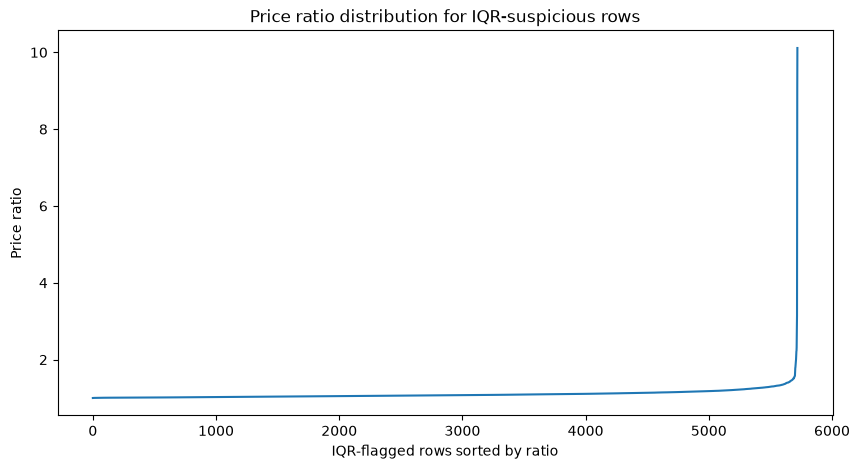

In [497]:


ratios = iqr_suspicious["price_ratio"].sort_values().reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.plot(ratios)
plt.xlabel("IQR-flagged rows sorted by ratio")
plt.ylabel("Price ratio")
plt.title("Price ratio distribution for IQR-suspicious rows")
plt.show()

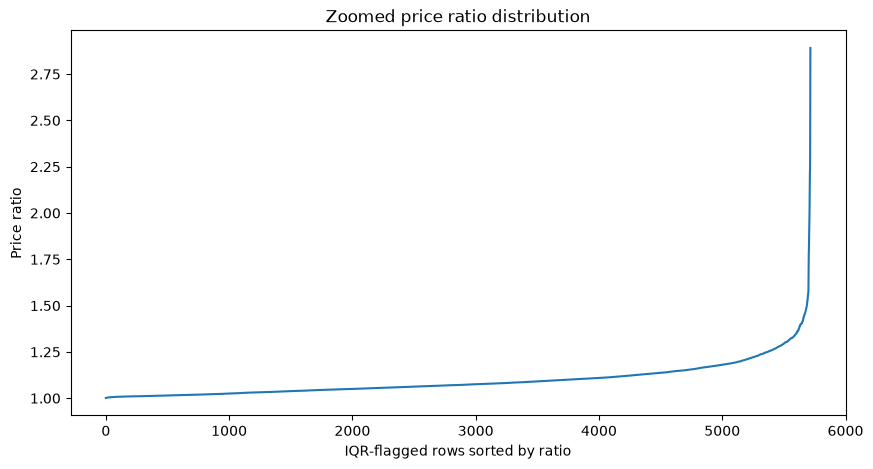

In [498]:
zoom = iqr_suspicious[
    iqr_suspicious["price_ratio"] <= 3
]["price_ratio"].sort_values().reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.plot(zoom)
plt.xlabel("IQR-flagged rows sorted by ratio")
plt.ylabel("Price ratio")
plt.title("Zoomed price ratio distribution")
plt.show()

In [499]:
iqr_suspicious["price_ratio"].quantile(
    [0.90, 0.95, 0.975, 0.99, 0.995, 0.999]
)

0.900    1.199386
0.950    1.268830
0.975    1.329947
0.990    1.440009
0.995    1.524242
0.999    2.378628
Name: price_ratio, dtype: float64

In [500]:
boundary = iqr_suspicious[
    iqr_suspicious["price_ratio"].between(1.5, 2.2)
].sort_values("price_ratio")

boundary[
    ["hash", "train_price", "median_price", "price_ratio", "upper_bound"]
].head(30)

,hash,train_price,median_price,price_ratio,upper_bound
805969,97538938487450067,52013.0,34616.5,1.502549,47156.750
1757398,9117162619636016315,29379.0,19544.0,1.503223,20937.125
2272707,12149203812519832282,65890.0,43810.0,1.503995,51787.500
1588353,14969950921417855673,56531.0,37102.0,1.523664,46966.500
2509464,15019743789185687713,38720.0,25410.0,1.523810,30703.875
2016352,13334622098546296759,36350.0,23838.0,1.524876,26421.750
748729,14672401067160493625,91935.0,60140.0,1.528683,80052.500
1362223,6020719356542274416,38490.0,24990.0,1.540216,35865.000
1373076,17559615606376657986,103225.0,66695.0,1.547717,102720.000
325340,15694201612550986439,62016.0,39868.5,1.555514,55235.625


In [501]:
suspicious_hash = 			16463018253638026196	  # put any hash here


In [502]:
suspicious_hash

16463018253638026196

In [503]:
boundary[boundary["hash"] == suspicious_hash]

,hash,train_price,median_price,price_ratio,Q1,Q3,IQR,lower_bound,upper_bound
2039221,16463018253638026196,129495.0,65845.0,1.966664,63088.75,82695.0,19606.25,33679.375,112104.375


In [504]:
rows = X_train.loc[train_hashes == suspicious_hash].copy()
rows["price"] = y_train.loc[rows.index]

rows[
    [
        "make_name",
        "model_name",
        "year",
        "trim_name",
        "mileage",
        "is_new",
        "price"
    ]
].sort_values("price", ascending=False)

,make_name,model_name,year,trim_name,mileage,is_new,price
2039221,Ford,F-550 Super Duty Chassis,2020,Unknown,5.0,True,129495.0
2038725,Ford,F-550 Super Duty Chassis,2020,Unknown,5.0,True,67095.0
2038539,Ford,F-550 Super Duty Chassis,2020,Unknown,5.0,True,64595.0
2038003,Ford,F-550 Super Duty Chassis,2020,Unknown,5.0,True,58570.0


In [505]:
final_suspects = iqr_suspicious[
    iqr_suspicious["price_ratio"] >= 2.0
].copy()

final_suspects.shape

(12, 9)

In [506]:
final_suspects[
    ["hash", "train_price", "median_price", "price_ratio", "upper_bound"]
].sort_values("price_ratio", ascending=False)

,hash,train_price,median_price,price_ratio,upper_bound
185103,5492722262828514893,320150.0,31657.5,10.112927,213035.000
908517,6713839979747926329,421780.0,46421.0,9.085974,74813.500
908511,6713839979747926329,388860.0,46421.0,8.376812,74813.500
1013302,4385675512980245731,44895.0,14245.0,3.151632,35745.000
622652,2201697772946513314,115625.0,39995.5,2.890950,88019.000
2432566,191194700731645102,110625.0,43760.0,2.527994,57956.250
1959688,2089821197251354055,124992.0,53870.0,2.320252,57615.500
1729199,6889850549483076157,133995.0,59995.0,2.233436,96507.500
2551158,8735702626827990070,122523.0,55273.0,2.216688,68584.500
1161322,11332543365454279981,99795.0,45949.0,2.171864,68165.500


In [507]:
suspect_hashes = final_suspects["hash"].unique()

for h in suspect_hashes:
    rows = X_train.loc[train_hashes == h].copy()
    rows["price"] = y_train.loc[rows.index]

    print("\nHASH:", h)

    display(
        rows[
            [
                "make_name",
                "model_name",
                "year",
                "trim_name",
                "mileage",
                "is_new",
                "price"
            ]
        ].sort_values("price", ascending=False)
    )


HASH: 5492722262828514893


,make_name,model_name,year,trim_name,mileage,is_new,price
185103,Jeep,Compass,2021,Unknown,6.0,True,320150.0
184545,Jeep,Compass,2021,Unknown,6.0,True,31780.0
184542,Jeep,Compass,2021,Unknown,6.0,True,31535.0
184264,Jeep,Compass,2021,Unknown,6.0,True,29785.0



HASH: 6713839979747926329


,make_name,model_name,year,trim_name,mileage,is_new,price
908517,GMC,Acadia,2021,Unknown,5.0,True,421780.0
908511,GMC,Acadia,2021,Unknown,5.0,True,388860.0
907354,GMC,Acadia,2021,Unknown,5.0,True,51991.0
907289,GMC,Acadia,2021,Unknown,5.0,True,51787.0
907284,GMC,Acadia,2021,Unknown,5.0,True,51433.0
907875,GMC,Acadia,2021,Unknown,5.0,True,50154.0
907663,GMC,Acadia,2021,Unknown,5.0,True,48727.0
907648,GMC,Acadia,2021,Unknown,5.0,True,48169.0
907369,GMC,Acadia,2021,Unknown,5.0,True,46421.0
907320,GMC,Acadia,2021,Unknown,5.0,True,42407.0



HASH: 4385675512980245731


...

,make_name,model_name,year,trim_name,mileage,is_new,price
1161322,Ford,F-150,2020,Unknown,9.0,True,99795.0
1161170,Ford,F-150,2020,Unknown,9.0,True,60844.0
1160634,Ford,F-150,2020,Unknown,9.0,True,53508.0
1160624,Ford,F-150,2020,Unknown,9.0,True,53348.0
1160922,Ford,F-150,2020,Unknown,9.0,True,52810.0
1160849,Ford,F-150,2020,Unknown,9.0,True,52415.0
1160770,Ford,F-150,2020,Unknown,9.0,True,52221.0
1160328,Ford,F-150,2020,Unknown,9.0,True,48706.0
1160320,Ford,F-150,2020,Unknown,9.0,True,47584.0
1160281,Ford,F-150,2020,Unknown,9.0,True,46846.0



HASH: 8204408092826420761


,make_name,model_name,year,trim_name,mileage,is_new,price
639585,Ford,F-550 Super Duty Chassis,2020,Unknown,10.0,True,124950.0
639534,Ford,F-550 Super Duty Chassis,2020,Unknown,10.0,True,63230.0
639665,Ford,F-550 Super Duty Chassis,2020,Unknown,10.0,True,61320.0
639648,Ford,F-550 Super Duty Chassis,2020,Unknown,10.0,True,59420.0
639623,Ford,F-550 Super Duty Chassis,2020,Unknown,10.0,True,58725.0
639532,Ford,F-550 Super Duty Chassis,2020,Unknown,10.0,True,49035.0
639856,Ford,F-550 Super Duty Chassis,2020,Unknown,10.0,True,46240.0



HASH: 18233584322250405731


,make_name,model_name,year,trim_name,mileage,is_new,price
2453528,Chevrolet,Bolt EV,2020,LT FWD,4.0,True,40479.0
1894930,Chevrolet,Bolt EV,2020,LT FWD,4.0,True,20790.0
1894825,Chevrolet,Bolt EV,2020,LT FWD,4.0,True,19645.0
1894787,Chevrolet,Bolt EV,2020,LT FWD,4.0,True,19495.0


In [508]:
ratio_only_suspects = train_analysis[
    train_analysis["price_ratio"] >= 2.0
].sort_values("price_ratio", ascending=False)

ratio_only_suspects.shape

(13, 9)

In [509]:
missed_by_iqr = ratio_only_suspects[
    ~ratio_only_suspects.index.isin(final_suspects.index)
]

missed_by_iqr[
    ["hash", "train_price", "median_price", "price_ratio"]
].sort_values("price_ratio", ascending=False)

,hash,train_price,median_price,price_ratio
1303333,11453892623244399690,129971.0,58366.0,2.226827


In [510]:
train_analysis[
    train_analysis["hash"] == 16468349563739211745
]

,hash,train_price,median_price,price_ratio,Q1,Q3,IQR,lower_bound,upper_bound
2537100,16468349563739211745,1116711.0,587780.5,1.899878,323315.25,852245.75,528930.5,-470080.5,1645641.5
2535958,16468349563739211745,58850.0,587780.5,0.100122,323315.25,852245.75,528930.5,-470080.5,1645641.5


In [511]:
hash_sizes = train_analysis["hash"].value_counts()

In [512]:
two_row_hashes = hash_sizes[hash_sizes == 2].index

In [513]:
two_row_groups = train_analysis[
    train_analysis["hash"].isin(two_row_hashes)
].copy()

In [514]:
len(two_row_hashes)

82198

In [515]:
two_row_groups.shape

(164396, 9)

In [516]:
two_row_stats = (
    two_row_groups
    .groupby("hash")["train_price"]
    .agg(low_price="min", high_price="max")
)

two_row_stats["pair_ratio"] = (
    two_row_stats["high_price"] /
    two_row_stats["low_price"]
)

In [517]:
two_row_stats.sort_values(
    "pair_ratio",
    ascending=False
).head(50)

,low_price,high_price,pair_ratio
hash,,,
16468349563739211745,58850.0,1116711.0,18.975548
14803983939421439104,33530.0,404843.0,12.074053
5819295803134546611,48395.0,492300.0,10.172538
4584339353417299132,61470.0,496302.0,8.073890
14084691165661291626,5495.0,21995.0,4.002730
4552947140140772645,25725.0,99999.0,3.887230
8617653938838525900,9995.0,32995.0,3.301151
17289268863822870986,10695.0,34950.0,3.267882
75363959543758810,46850.0,138250.0,2.950907


In [518]:
suspicious_hash = 17289268863822870986		   # replace with any 2-row hash

rows = X_train.loc[train_hashes == suspicious_hash].copy()
rows["price"] = y_train.loc[rows.index]

display(
    rows[
        [
            "make_name",
            "model_name",
            "year",
            "trim_name",
            "mileage",
            "is_new",
            "price"
        ]
    ].sort_values("price", ascending=False)
)

display(two_row_stats.loc[[suspicious_hash]])

,make_name,model_name,year,trim_name,mileage,is_new,price
1942058,Chrysler,Town & Country,2014,Touring FWD,41308.0,False,34950.0
1941346,Chrysler,Town & Country,2014,Touring FWD,41308.0,False,10695.0


,low_price,high_price,pair_ratio
hash,,,
17289268863822870986,10695.0,34950.0,3.267882


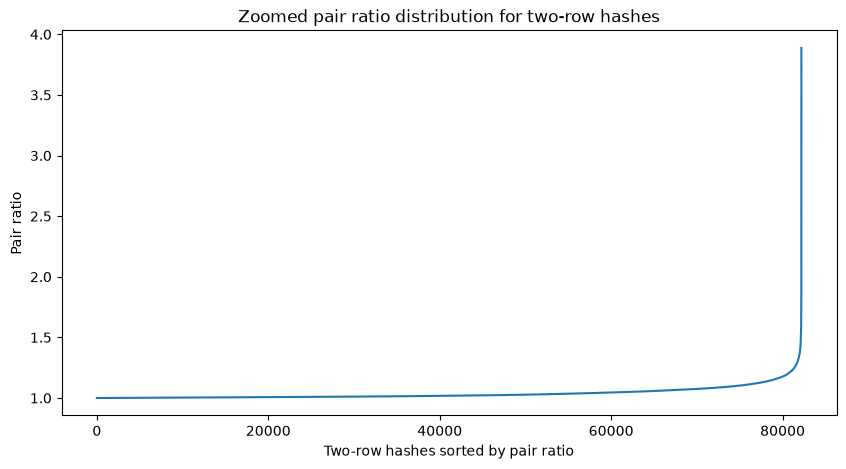

In [519]:


pair_ratios = (
    two_row_stats["pair_ratio"]
    .sort_values()
    .reset_index(drop=True)
)

zoom_pair = pair_ratios[pair_ratios <= 4]

plt.figure(figsize=(10, 5))

plt.plot(zoom_pair)

plt.xlabel("Two-row hashes sorted by pair ratio")
plt.ylabel("Pair ratio")
plt.title("Zoomed pair ratio distribution for two-row hashes")

plt.show()

In [520]:
bad_two_row_hashes = two_row_stats.loc[two_row_stats["pair_ratio"] >= 3]
bad_two_row_groups = two_row_groups[
    two_row_groups["hash"].isin(bad_two_row_hashes.index)
]
two_rows_suspicious = bad_two_row_groups.groupby('hash')['train_price'].idxmax()

In [521]:
three_plus_hashes = hash_sizes[hash_sizes >= 3].index
three_plus_groups = train_analysis[
    train_analysis["hash"].isin(three_plus_hashes)
]
three_plus_suspicious = three_plus_groups[
    (three_plus_groups["train_price"] > three_plus_groups["upper_bound"]) &
    (three_plus_groups["price_ratio"] >= 2.0)
]

In [522]:
three_plus_suspicious.shape

(12, 9)

In [523]:
two_rows_suspicious.shape

(8,)

In [524]:
bad_row_indices = pd.Index(two_rows_suspicious.values).union(three_plus_suspicious.index)

In [525]:
len(bad_row_indices)

20

In [526]:
check_bad_rows = X_train.loc[bad_row_indices].copy()
check_bad_rows["price"] = y_train.loc[bad_row_indices]

check_bad_rows

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,transmission,trim_name,wheel_system,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,price
185103,Yonkers,I4,Not Reported,Gasoline,Not Reported,180.0,True,Jeep,6.0,Compass,...,A,Unknown,Unknown,2021,0,1,False,False,False,320150.0
453533,Attica,Unknown,Not Reported,Unknown,Not Reported,345.0,True,Chevrolet,3.0,Blazer,...,A,Unknown,Unknown,2021,0,1,False,False,False,492300.0
622652,Sterling,V8 Flex Fuel Vehicle,Not Reported,Flex Fuel Vehicle,Not Reported,381.0,True,Ford,0.0,F-150,...,A,Unknown,Unknown,2020,0,1,False,False,False,115625.0
639585,Pittsburgh,Unknown,Not Reported,Unknown,Not Reported,345.0,True,Ford,10.0,F-550 Super Duty Chassis,...,A,Unknown,Unknown,2020,0,1,False,False,False,124950.0
908511,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,388860.0
908517,Charlotte,Unknown,Not Reported,Unknown,Not Reported,345.0,True,GMC,5.0,Acadia,...,A,Unknown,Unknown,2021,0,1,False,False,False,421780.0
1008668,Cadillac,Unknown,False,Unknown,False,345.0,False,Ford,41308.0,Thunderbird,...,Unknown,Unknown,Unknown,1964,1,1,False,True,True,21995.0
1009519,Cadillac,Unknown,False,Unknown,False,345.0,False,Ford,41308.0,Thunderbird,...,Unknown,Unknown,Unknown,1960,1,1,False,True,True,32995.0
1013302,Cadillac,Unknown,False,Unknown,False,345.0,False,Ford,41308.0,Model A,...,Unknown,Pickup,Unknown,1930,1,1,False,True,True,44895.0
1075207,Blackshear,I4,Not Reported,Gasoline,Not Reported,180.0,True,Ford,15.0,Ranger,...,A,Unknown,Unknown,2020,0,1,False,False,False,404843.0


In [527]:
X_train = X_train.drop(bad_row_indices)
y_train = y_train.drop(bad_row_indices)

In [528]:
X_train.shape


(2130184, 21)

In [529]:
y_train.shape

(2130184,)

CLEANINING X_VAL

In [530]:
val_analysis = (
    pd.DataFrame({
        "hash": pd.util.hash_pandas_object(X_val, index=False),
        "val_price": y_val
    })
)

val_analysis= val_analysis[
    val_analysis["hash"].duplicated(keep=False)
]

val_analysis["median_price"] = (
   val_analysis.groupby("hash")["val_price"]
    .transform("median")
)

val_analysis["price_ratio"] = (
    val_analysis["val_price"] /
    val_analysis["median_price"]
)

val_analysis = val_analysis.sort_values(
    "price_ratio",
    ascending=False
)

In [531]:
val_analysis.head()

,hash,val_price,median_price,price_ratio
908532,6713839979747926329,425460.0,238202.5,1.786127
908527,6713839979747926329,424060.0,238202.5,1.780250
2511320,7857622907184052868,101990.0,60865.0,1.675676
2029346,17424550300824787788,94415.0,57875.0,1.631361
797883,17911252449072787895,61999.0,40432.0,1.533414


In [532]:
q1 = val_analysis.groupby("hash")["val_price"].transform("quantile", 0.25)
q3 = val_analysis.groupby("hash")["val_price"].transform("quantile", 0.75)

val_analysis["Q1"] = q1
val_analysis["Q3"] = q3
val_analysis["IQR"] = q3 - q1

val_analysis["lower_bound"] = q1 - 1.5 * val_analysis["IQR"]
val_analysis["upper_bound"] = q3 + 1.5 * val_analysis["IQR"]

In [533]:
iqr_val_suspicious = val_analysis[
   val_analysis["val_price"] > val_analysis["upper_bound"]
]

In [534]:
iqr_val_suspicious.shape

(50, 9)

In [535]:
iqr_val_suspicious[
    ["hash", "val_price", "median_price", "price_ratio", "upper_bound"]
].sort_values("price_ratio", ascending=False).head(50)

,hash,val_price,median_price,price_ratio,upper_bound
622688,15959963670867179595,62360.0,42919.0,1.452970,48081.500
2111986,11953677181499587499,61073.0,42695.5,1.430432,57701.125
808040,8068587227830895646,94724.0,69457.0,1.363779,90670.125
814660,8130347717199463062,115845.0,85545.0,1.354200,93995.000
1989808,13967549656123344849,82730.0,64692.5,1.278819,78550.625
326605,4320656253568864056,61235.0,49035.5,1.248789,50974.125
1178408,12402627806213711917,50126.0,40493.5,1.237878,47832.500
1330141,293682531988728249,60695.0,49360.0,1.229639,59731.250
863508,13498212496571669789,61670.0,50645.0,1.217692,59960.000
2332010,5455009282305472071,56890.0,47515.0,1.197306,48532.500


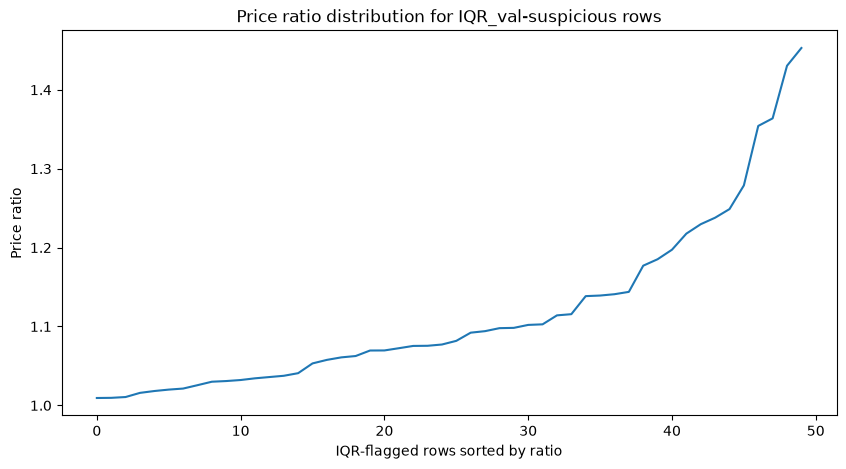

In [536]:
ratios = iqr_val_suspicious["price_ratio"].sort_values().reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.plot(ratios)
plt.xlabel("IQR-flagged rows sorted by ratio")
plt.ylabel("Price ratio")
plt.title("Price ratio distribution for IQR_val-suspicious rows")
plt.show()

In [537]:
val_hash_sizes = val_analysis["hash"].value_counts()

In [538]:
two_row_val_hashes = val_hash_sizes[val_hash_sizes == 2].index
three_plus_val_hashes = val_hash_sizes[val_hash_sizes >= 3].index

In [539]:
two_row_val_groups = val_analysis[
    val_analysis["hash"].isin(two_row_val_hashes)
].copy()
two_row_val_stats = (
    two_row_val_groups.groupby("hash")["val_price"]
    .agg(low_price="min", high_price="max")
)
two_row_val_stats["pair_ratio"] = (
    two_row_val_stats["high_price"] /
    two_row_val_stats["low_price"]
)
two_row_val_stats.sort_values("pair_ratio", ascending=False).head(20)

,low_price,high_price,pair_ratio
hash,,,
13579105420511379995,24590.0,39590.0,1.610004
11001939672563169621,58535.0,90285.0,1.542411
7465634063200053784,17999.0,27727.0,1.540474
18202781315508261836,33815.0,51945.0,1.536153
6788668666293423460,19436.0,29752.0,1.530768
17743091459694689801,18999.0,28159.0,1.482131
11208782900687972099,22199.0,32870.0,1.480697
15589952174878495866,39682.0,58370.0,1.470944
1171148906992420713,40258.0,59167.0,1.469695


In [540]:
three_plus_val_groups = val_analysis[
    val_analysis["hash"].isin(three_plus_val_hashes)
]
three_plus_val_suspicious = three_plus_val_groups[
    (three_plus_val_groups["val_price"] > three_plus_val_groups["upper_bound"]) &
    (three_plus_val_groups["price_ratio"] >= 2)
]
three_plus_val_suspicious

,hash,val_price,median_price,price_ratio,Q1,Q3,IQR,lower_bound,upper_bound


In [541]:
val_group_spread = (
    val_analysis.groupby("hash")["val_price"]
    .agg(
        min_price="min",
        max_price="max",
        group_size="size"
    )
)

val_group_spread["spread_ratio"] = (
    val_group_spread["max_price"] /
    val_group_spread["min_price"]
)

val_group_spread.sort_values(
    "spread_ratio",
    ascending=False
).head(20)

,min_price,max_price,group_size,spread_ratio
hash,,,,
6713839979747926329,42867.0,425460.0,4,9.925117
11953677181499587499,35194.0,61073.0,10,1.735324
7857622907184052868,59870.0,101990.0,3,1.703524
10059650035534403879,14764.0,24605.0,4,1.666554
17424550300824787788,56845.0,94415.0,3,1.660920
18053596870380668419,41470.0,66915.0,4,1.613576
13579105420511379995,24590.0,39590.0,2,1.610004
17911252449072787895,38995.0,61999.0,3,1.589922
13378688536895829475,42010.0,66775.0,4,1.589502


In [542]:
bad_hash = 6713839979747926329

val_analysis[
    val_analysis["hash"] == bad_hash
]

,hash,val_price,median_price,price_ratio,Q1,Q3,IQR,lower_bound,upper_bound
908532,6713839979747926329,425460.0,238202.5,1.786127,49975.5,424410.0,374434.5,-511676.25,986061.75
908527,6713839979747926329,424060.0,238202.5,1.780250,49975.5,424410.0,374434.5,-511676.25,986061.75
907359,6713839979747926329,52345.0,238202.5,0.219750,49975.5,424410.0,374434.5,-511676.25,986061.75
907408,6713839979747926329,42867.0,238202.5,0.179960,49975.5,424410.0,374434.5,-511676.25,986061.75


In [543]:
bad_val_indices = [908532, 908527]

X_val = X_val.drop(bad_val_indices)
y_val = y_val.drop(bad_val_indices)

In [544]:
X_train.shape
y_train.shape

(2130184,)

In [551]:
X_val.shape
y_val.shape

(266269,)

In [545]:
categorical_cols = ['city', 'make_name', 'model_name','trim_name','engine_type','frame_damaged','fuel_type','has_accidents','salvage','transmission','wheel_system'] 

categoric_transformer= ('cat', OneHotEncoder(handle_unknown = 'ignore'), categorical_cols)


numerical_cols = ['horsepower', 'mileage', 'owner_count', 'year']
numeric_transformer = ('num', StandardScaler(), numerical_cols)



boolean_cols =['is_new',
 'mileage_missing',
 'horsepower_missing',
 'Condition_reported',
 'new_mileage_conflict',
 'used_owner_count_missing'] 
boolean_transformer = ("bool", "passthrough", boolean_cols)

preprocessor = ColumnTransformer(
    transformers=[
        numeric_transformer,
        categoric_transformer,
        boolean_transformer
    ]
)

In [546]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [549]:
X_train_processed.shape


(2130184, 14590)

In [550]:
X_val_processed.shape

(266269, 14590)

In [553]:
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)
y_pred = lr_model.predict(X_val_processed)
y_prediction = lr_model.predict(X_train_processed)
t_prediction = lr_model.predict(X_test_processed)

In [554]:
mae = mean_absolute_error(y_val,y_pred)
val_rmse = np.sqrt(mean_squared_error(y_val,y_pred))
train_rmse = np.sqrt(mean_squared_error(y_train, y_prediction))
test_rmse = np.sqrt(mean_squared_error(y_test, t_prediction))
r2 = r2_score(y_val, y_pred)


print("MAE:", mae)
print("Val_rmse:", val_rmse)
print("train_rmse:",train_rmse)
print("test_rmse:",test_rmse)
print("r2:", r2)

MAE: 3019.4784295125764
Val_rmse: 5356.102082700684
train_rmse: 6511.8053820015075
test_rmse: 8034.215723597411
r2: 0.9220553909883207


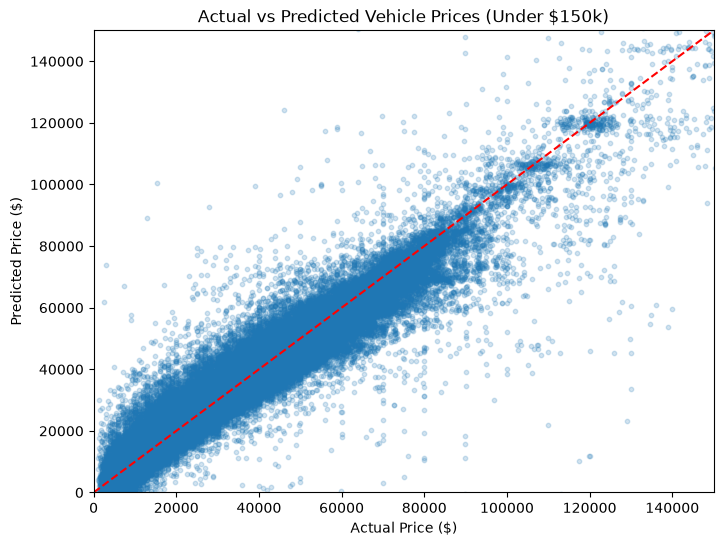

In [555]:
plt.figure(figsize=(8, 6))

plt.scatter(y_val, y_pred, alpha=0.2, s=10)

plt.plot(
    [0, 150000],
    [0, 150000],
    linestyle="--",
    color="red"
)

plt.xlim(0, 150000)
plt.ylim(0, 150000)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Vehicle Prices (Under $150k)")

plt.show()

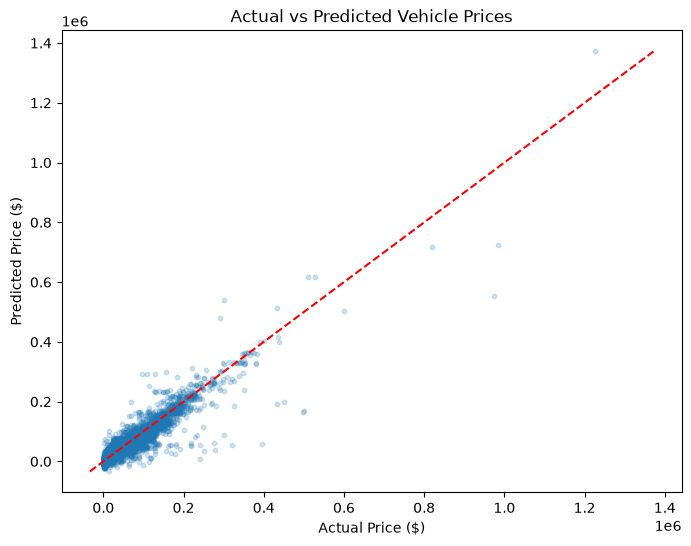

In [556]:
plt.figure(figsize=(8, 6))

plt.scatter(y_val, y_pred, alpha=0.2, s=10)

min_price = min(y_val.min(), y_pred.min())
max_price = max(y_val.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--",
    color="red"
)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Vehicle Prices")

plt.show()

In [557]:
val_errors = X_val.copy()

val_errors["actual_price"] = y_val
val_errors["predicted_price"] = y_pred
val_errors["error"] = y_val - y_pred
val_errors["abs_error"] = abs(y_val - y_pred)

In [558]:
val_errors.sort_values("abs_error", ascending=False)

,city,engine_type,frame_damaged,fuel_type,has_accidents,horsepower,is_new,make_name,mileage,model_name,...,year,mileage_missing,horsepower_missing,new_mileage_conflict,used_owner_count_missing,Condition_reported,actual_price,predicted_price,error,abs_error
2256267,Spring,V6,False,Gasoline,False,647.0,False,Ford,80.0,GT,...,2017,0,0,False,False,True,975000.0,552415.320241,422584.679759,422584.679759
2478581,Van Nuys,Unknown,False,Unknown,False,345.0,False,Rolls-Royce,52248.0,Silver Cloud,...,1959,0,1,False,True,True,395000.0,57750.993480,337249.006520,337249.006520
158297,Great Neck,H6,False,Gasoline,False,424.0,False,Porsche,18296.0,911,...,1997,0,0,False,False,True,499000.0,163839.756148,335160.243852,335160.243852
2091354,Austin,V8,False,Gasoline,False,583.0,False,Mercedes-Benz,880.0,SLS-Class,...,2015,0,0,False,False,True,499900.0,168914.980208,330985.019792,330985.019792
2635222,San Carlos,Unknown,False,Unknown,False,345.0,False,Mercedes-Benz,80481.0,300-Class,...,1972,0,1,False,True,True,319995.0,56424.535966,263570.464034,263570.464034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144677,San Antonio,V6,False,Gasoline,False,285.0,False,Jeep,14719.0,Wrangler Unlimited,...,2018,0,0,False,False,True,34852.0,34852.033513,-0.033513,0.033513
1223907,Tampa,I4,False,Gasoline,False,180.0,False,Mercedes-Benz,82425.0,C-Class,...,2013,0,1,False,False,True,12995.0,12995.027765,-0.027765,0.027765
1817507,Chesterfield,V8,False,Gasoline,False,370.0,False,Dodge,47823.0,Charger,...,2018,0,0,False,False,True,27363.0,27363.021996,-0.021996,0.021996
135879,Washington,V6,False,Gasoline,True,290.0,False,Ford,101233.0,Explorer,...,2013,0,0,False,False,True,13987.0,13986.986568,0.013432,0.013432


In [559]:
val_errors.sort_values("abs_error", ascending=False)[
    [
        "make_name",
        "model_name",
        "year",
        "trim_name",
        "mileage",
        "is_new",
        "actual_price",
        "predicted_price",
        "abs_error"
    ]
].head(20)

,make_name,model_name,year,trim_name,mileage,is_new,actual_price,predicted_price,abs_error
2256267,Ford,GT,2017,RWD,80.0,False,975000.0,552415.320241,422584.679759
2478581,Rolls-Royce,Silver Cloud,1959,Drophead Coupe,52248.0,False,395000.0,57750.993480,337249.006520
158297,Porsche,911,1997,Turbo S AWD,18296.0,False,499000.0,163839.756148,335160.243852
2091354,Mercedes-Benz,SLS-Class,2015,AMG GT Final Edition Roadster,880.0,False,499900.0,168914.980208,330985.019792
2635222,Mercedes-Benz,300-Class,1972,Unknown,80481.0,False,319995.0,56424.535966,263570.464034
488893,Porsche,Carrera GT,2005,2 Dr STD Convertible,338.0,False,984900.0,722970.470658,261929.529342
153739,Rolls-Royce,Ghost,2020,RWD,30.0,True,450450.0,197574.824350,252875.175650
2613879,Ford,GT,2005,RWD,3024.0,False,299988.0,540933.114654,240945.114654
706271,Chevrolet,Corvette,1958,Unknown,164.0,False,279000.0,38664.679432,240335.320568
1382949,Rolls-Royce,Ghost,2020,RWD,6.0,True,432500.0,192561.622846,239938.377154


RIGDE REGRESSION

In [560]:
print(X_train_processed.shape)
print(y_train.shape)

(2130184, 14590)
(2130184,)


In [566]:
ridge_model = Ridge(alpha=0.01)

ridge_model.fit(X_train_processed, y_train)

ridge_val_pred = ridge_model.predict(X_val_processed)
ridge_train_pred = ridge_model.predict(X_train_processed)

ridge_mae = mean_absolute_error(y_val, ridge_val_pred)

ridge_val_rmse = np.sqrt(
    mean_squared_error(y_val, ridge_val_pred)
)

ridge_train_rmse = np.sqrt(
    mean_squared_error(y_train, ridge_train_pred)
)

ridge_r2 = r2_score(y_val, ridge_val_pred)

print("Ridge MAE:", ridge_mae)
print("Ridge Val RMSE:", ridge_val_rmse)
print("Ridge Train RMSE:", ridge_train_rmse)
print("Ridge R²:", ridge_r2)

Ridge MAE: 3021.0334588097035
Ridge Val RMSE: 5357.995711100291
Ridge Train RMSE: 6524.649437747416
Ridge R²: 0.9220002672381368
